# Laboratory Assignment 05
## GAN Architecture and Forward-Pass Testing

**Name:** Rudra Pratap Singh  
**Roll No.:** 23SCSE1180423  
**Course:** Generative AI  
**Program:** B.Tech. (AIML)  
**Semester:** 7th  
**Academic Year:** 2026–27  

### Objective
To implement and inspect the Generator and Discriminator components
of a basic GAN using PyTorch and perform forward-pass testing on MNIST images.

## Import Required Libraries

PyTorch and Torchvision are used to implement the Generator,
Discriminator and load the MNIST dataset.

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cu128


# Question 1: Generator Architecture

The Generator takes a random latent noise vector of size 100
and transforms it into a 28 × 28 grayscale image.

In [ ]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Latent vector size
latent_dim = 100

# Generate random noise for a batch of 16
noise = torch.randn(16, latent_dim).to(device)

print("Input noise shape:", noise.shape)

Using device: cuda
Input noise shape: torch.Size([16, 100])


### Define the Generator

The Generator uses Linear and ReLU layers to transform the
100-dimensional latent vector into a 28 × 28 grayscale image.

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        return x.view(-1, 1, 28, 28)


generator = Generator(latent_dim).to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)


### Generator Parameter Count and Output Shape

In [ ]:
# Count trainable parameters
generator_parameters = sum(
    p.numel() for p in generator.parameters()
    if p.requires_grad
)

# Forward pass
generated_images = generator(noise)

print("Number of trainable parameters:", generator_parameters)
print("Generator output shape:", generated_images.shape)

Number of trainable parameters: 1486352
Generator output shape: torch.Size([16, 1, 28, 28])


# Question 2: Discriminator Architecture

The Discriminator accepts a 28 × 28 grayscale image and produces
a single probability value between 0 and 1.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.model(x)


discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


### Load MNIST Dataset

The MNIST dataset provides real grayscale handwritten digit images.
The images are normalized before being passed to the Discriminator.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

real_images, labels = next(iter(dataloader))

real_images = real_images.to(device)

print("Real image batch shape:", real_images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.78MB/s]

Real image batch shape: torch.Size([16, 1, 28, 28])


### Discriminator Output for Real Images

In [ ]:
with torch.no_grad():
    real_output = discriminator(real_images)

print("Discriminator output shape for real images:", real_output.shape)
print("\nDiscriminator outputs for real images:")
print(real_output)

Discriminator output shape for real images: torch.Size([16, 1])

Discriminator outputs for real images:
tensor([[0.4882],
        [0.4981],
        [0.4854],
        [0.5020],
        [0.4950],
        [0.5143],
        [0.4707],
        [0.4792],
        [0.4882],
        [0.4908],
        [0.4905],
        [0.4900],
        [0.4708],
        [0.4701],
        [0.5029],
        [0.4901]], device='cuda:0')


### Discriminator Output for Generated Images

In [ ]:
with torch.no_grad():
    fake_output = discriminator(generated_images)

print("Discriminator output shape for generated images:", fake_output.shape)
print("\nDiscriminator outputs for generated images:")
print(fake_output)

Discriminator output shape for generated images: torch.Size([16, 1])

Discriminator outputs for generated images:
tensor([[0.4883],
        [0.4895],
        [0.4883],
        [0.4886],
        [0.4885],
        [0.4876],
        [0.4887],
        [0.4898],
        [0.4890],
        [0.4894],
        [0.4889],
        [0.4894],
        [0.4879],
        [0.4898],
        [0.4885],
        [0.4884]], device='cuda:0')


# Question 3: End-to-End GAN Architecture Testing

The complete forward pass is tested using the following pipeline:

Noise → Generator → Generated Image → Discriminator → Output

In [ ]:
# Generate a fresh batch of 16 random noise vectors
noise = torch.randn(16, latent_dim).to(device)

with torch.no_grad():

    # Noise → Generator
    generated_images = generator(noise)

    # Generated Image → Discriminator
    discriminator_output = discriminator(generated_images)

print("End-to-End GAN Architecture")
print("-" * 40)

print("Noise shape                 :", noise.shape)
print("Generator output shape     :", generated_images.shape)
print("Generated image shape      :", generated_images.shape)
print("Discriminator output shape :", discriminator_output.shape)

End-to-End GAN Architecture
----------------------------------------
Noise shape                 : torch.Size([16, 100])
Generator output shape     : torch.Size([16, 1, 28, 28])
Generated image shape      : torch.Size([16, 1, 28, 28])
Discriminator output shape : torch.Size([16, 1])


### Generated Images

The Generator output is visualized as a 4 × 4 grid containing
16 generated grayscale images.

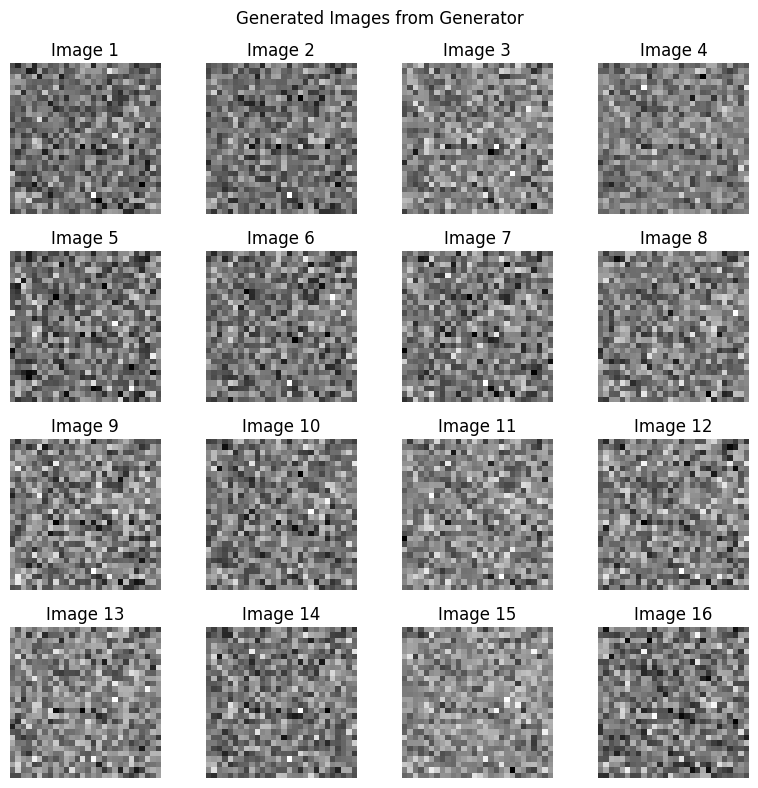

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image = generated_images[i].cpu().squeeze().numpy()

    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(f"Image {i+1}")

plt.suptitle("Generated Images from Generator")
plt.tight_layout()
plt.show()

## Observations

1. The Generator accepts a batch of 16 latent noise vectors, where each
   noise vector has a dimension of 100, and produces images of shape
   1 × 28 × 28.

2. The Discriminator accepts 28 × 28 grayscale images and produces one
   probability value for each image.

3. The complete forward-pass flow successfully follows:
   Noise → Generator → Generated Image → Discriminator → Output.

4. Since the Generator is not trained in this assignment, the generated
   images appear random and do not necessarily resemble recognizable
   handwritten digits.

## Conclusion

In this laboratory assignment, the major components of a basic GAN
architecture were implemented and inspected using PyTorch.

A Generator was created using a 100-dimensional latent noise vector
as input and Linear and ReLU layers to generate 28 × 28 grayscale
images. The number of trainable parameters and the Generator output
tensor shape were verified.

A Discriminator was also implemented to accept 28 × 28 grayscale
images and produce a single probability value. Real MNIST images and
generated images were passed through the Discriminator to verify its
output shape and values.

Finally, an end-to-end forward pass was performed through the complete
GAN pipeline:

Noise → Generator → Generated Image → Discriminator → Output

A batch of 16 generated images was also visualized in a 4 × 4 grid.
The experiment successfully demonstrates the basic architecture and
tensor flow of a GAN.